In [1]:
import pandas as pd
import numpy as np

In [2]:
import statsmodels.api as sm 
from statsmodels.formula.api import ols
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
import statsmodels.formula.api as smf

In [4]:
import pingouin as pg

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [6]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'

In [7]:
df = pd.read_excel(fpath + '\\6.0_database_variables.xlsx')

# EDA

In [8]:
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'week(1=free days)': 'weekday_type'})

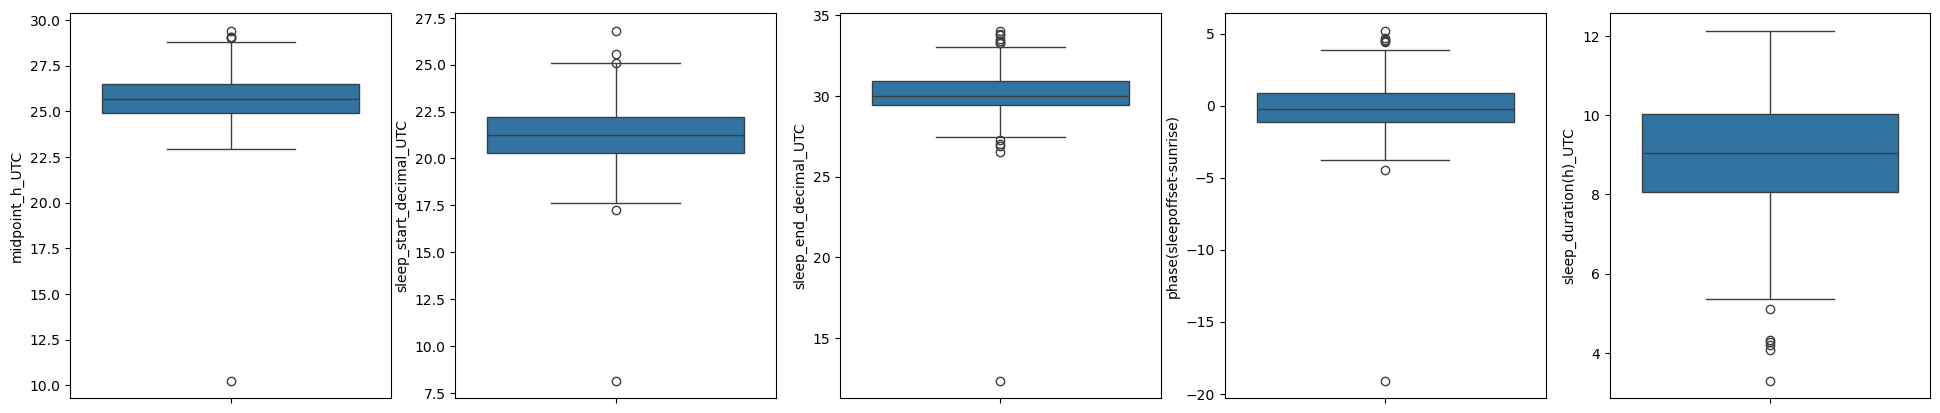

In [9]:
# box plot to verify the outliers in midpoint, sleep onset, sleep offset, phase, and sleep duration
fig, ax = plt.subplots(1, 5, figsize=(24, 5))
sns.boxplot(data=df['midpoint_h_UTC'], ax=ax[0])
sns.boxplot(data=df['sleep_start_decimal_UTC'], ax=ax[1])
sns.boxplot(data=df['sleep_end_decimal_UTC'], ax=ax[2])
sns.boxplot(data=df['phase(sleepoffset-sunrise)'], ax=ax[3])
sns.boxplot(data=df['sleep_duration(h)_UTC'], ax=ax[4])

plt.show()

In [10]:
# remove outliers
# criteria: zscore of 3 means that the data point is 3 standard deviations away from the mean
df = df[(np.abs(stats.zscore(df['sleep_duration(h)_UTC'])) < 3)] 
df = df[(np.abs(stats.zscore(df['midpoint_h_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]

In [11]:
df = df.drop('sunrise_time(USA)', axis=1)
df = df.drop('sunrise (USA), hours', axis=1)
df = df.drop('sunset (USA), hours', axis=1)
df = df.drop('sunset_time(USA)', axis=1)
df = df.drop('photoperiod (h, USA)', axis=1)

In [12]:
# Define the start date
start_date = pd.to_datetime('2022-02-01')

In [13]:
# Function to count the week of the year from the start date 2022-01-01
def calculate_week_of_year(start_datetime):
    return (start_datetime - start_date).days // 7 + 5

# Apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [14]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [15]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday_type'] = df['weekday_type'].map({0: 'work days', 1: 'free days'})

In [16]:
# calculate the sleep duration for work days and free days
df['sleep_duration(h)_UTC'] = df['sleep_duration(h)_UTC'].astype(float)
df['sleep_duration_work_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'work days')
df['sleep_duration_free_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'free days')

In [17]:
# filtered the midpoints by type of day of the week
# new dataframe with only the midpoints of the work days/free days
df_workdays = df[df['weekday_type'] == 'work days']
df_freedays = df[df['weekday_type'] == 'free days']

In [18]:
data_jetlag_UTC = df #df for weekly jetlag analysis

In [19]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag_UTC = data_jetlag_UTC.groupby(['location', 'week_of_year', 'weekday_type'])['midpoint_h_UTC'].mean().unstack()

In [20]:
weekly_means_jetlag_UTC['jet lag_UTC'] = weekly_means_jetlag_UTC['free days'] - weekly_means_jetlag_UTC['work days']

In [21]:
# add a column with the location
weekly_means_jetlag_UTC['location'] = weekly_means_jetlag_UTC.index.get_level_values(0)

In [22]:
weekly_means_jetlag_UTC.to_excel(fpath + '\\weekly_means_jetlag_UTC.xlsx')

In [23]:
df = df.rename(columns={'sleep_duration(h)_UTC': 'sleep_duration_UTC'})
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})

In [24]:
# Adding a 'season' column to the dataset based on the 'date' column
# Defining seasons based on months: 
# Winter (Dec-Feb), Spring (Mar-May), Summer (Jun-Aug), Autumn (Sep-Nov)
def assign_season(date):
    month = pd.to_datetime(date).month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

In [25]:
# Applying the function to create a season column
df_workdays['season'] = df_workdays['date'].apply(assign_season)
df_freedays['season'] = df_freedays['date'].apply(assign_season)
df['season'] = df['date'].apply(assign_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_26696\2974399819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays['season'] = df_workdays['date'].apply(assign_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_26696\2974399819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays['season'] = df_freedays['date'].apply(assign_season)


In [26]:
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df['photoperiod'] = np.where(df['location'] == 'UK', df['photoperiod (h, UK)'], df['photoperiod (h, ITA)'])
df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] # add a column with the photoperiod for the UK
df_workdays.loc[df_workdays['location'] == 'ITA', 'photoperiod'] = df_workdays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_26696\1293994927.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] # add a column with the photoperiod for the UK


In [27]:
df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']
df_freedays.loc[df_freedays['location'] == 'ITA', 'photoperiod'] = df_freedays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_26696\1486412571.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']


In [28]:
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

In [29]:
descriptive_ita = df[df['location'] == 'ITA'].describe()
descriptive_ita = descriptive_ita.transpose()

In [30]:
descriptive_uk = df[df['location'] == 'UK'].describe()
descriptive_uk = descriptive_uk.transpose()

In [31]:
#mean and std of the days_after_flight column
mean_days_after_flight = df['day_after_flight'].mean()
std_days_after_flight = df['day_after_flight'].std()

print('Mean of days after flight:', mean_days_after_flight)
print('Std of days after flight:', std_days_after_flight)

Mean of days after flight: 8.690812720848056
Std of days after flight: 6.212019782711081


In [32]:
# mean and std of the days_after_flight column by location
mean_days_after_flight_location = df.groupby('location')['day_after_flight'].mean()
std_days_after_flight_location = df.groupby('location')['day_after_flight'].std()

# concatenate the mean and std of the days_after_flight column by location in a single dataframe
mean_std_days_after_flight_location = pd.concat([mean_days_after_flight_location, std_days_after_flight_location], axis=1)
mean_std_days_after_flight_location.columns = ['mean', 'std']

In [33]:
mean_std_days_after_flight_location

,mean,std
location,,
ITA,9.863501,7.129692
UK,6.965066,3.961282


In [34]:
# count location as percentage
count_location = df['location'].value_counts(normalize=True) * 100

In [35]:
count_location

location
ITA    59.540636
UK     40.459364
Name: proportion, dtype: float64

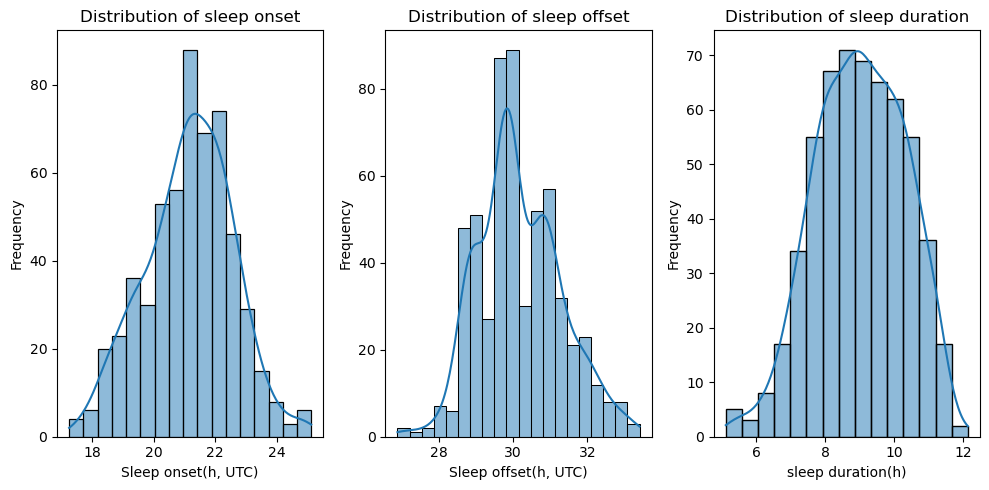

In [36]:
# Distribution 
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_start_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep onset")
plt.xlabel("Sleep onset(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(df['sleep_end_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep offset")
plt.xlabel("Sleep offset(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(df['sleep_duration_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep duration")
plt.xlabel("sleep duration(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

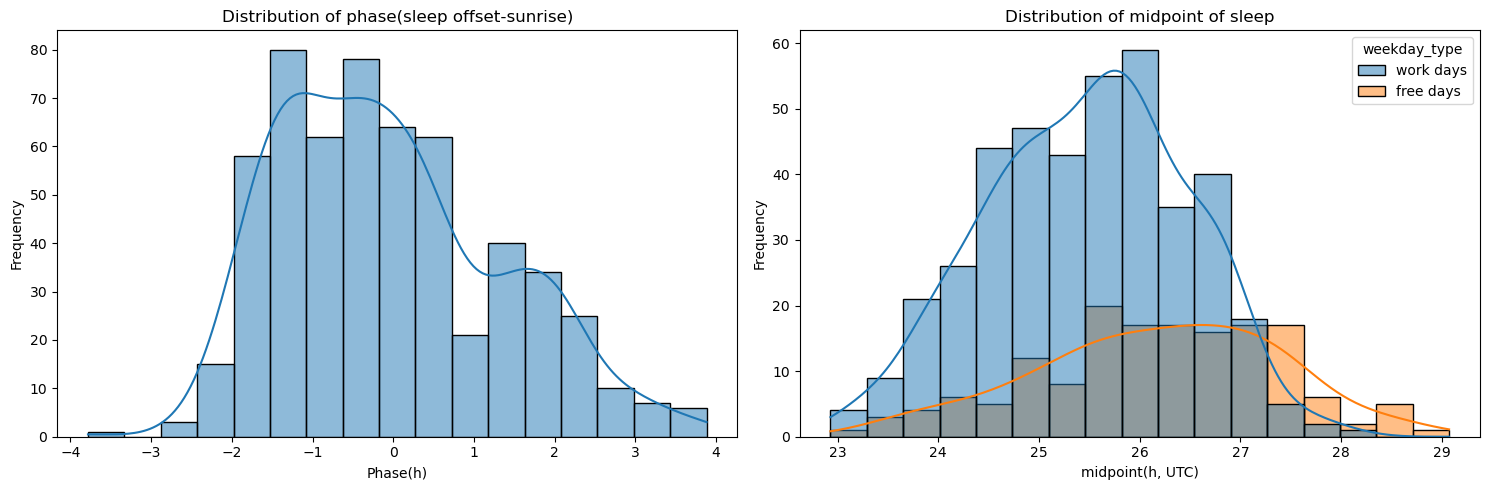

In [37]:
# Distribution 
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['phase'].dropna(), kde=True)
plt.title("Distribution of phase(sleep offset-sunrise)")
plt.xlabel("Phase(h)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='midpoint_h_UTC', hue='weekday_type', kde=True)
plt.title("Distribution of midpoint of sleep")
plt.xlabel("midpoint(h, UTC)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [38]:
# test normality of the data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration_UTC'])
shapiro_test_midpoint = stats.shapiro(df['midpoint_h_UTC'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal_UTC'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal_UTC'])
shapiro_test_phase = stats.shapiro(df['phase'])

In [39]:
shapiro_results_descriptive = pd.DataFrame({
    'Variable': ['sleep_duration(h)', 'midpoint_h_UTC', 'sleep_start_decimal_UTC', 'sleep_end_decimal_UTC', 'phase(sleepoffset-sunrise)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_midpoint, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase]
})

In [40]:
shapiro_results_descriptive

,Variable,Shapiro-Wilk test
0,sleep_duration(h),"(0.9902246610911858, 0.0008226033160291848)"
1,midpoint_h_UTC,"(0.9966098081502522, 0.27825571498290286)"
2,sleep_start_decimal_UTC,"(0.9938769987889519, 0.021848420182686012)"
3,sleep_end_decimal_UTC,"(0.9836545244937268, 5.6566874049762885e-06)"
4,phase(sleepoffset-sunrise),"(0.9661064505005437, 3.7966420613702094e-10)"


In [41]:
#shapiro of midpoint free days and work days
shapiro_test_midpoint_free = stats.shapiro(df[df['weekday_type'] == 'free days']['midpoint_h_UTC'])
shapiro_test_midpoint_work = stats.shapiro(df[df['weekday_type'] == 'work days']['midpoint_h_UTC'])

In [42]:
shapiro_results_free_work = pd.DataFrame({
    'Weekday type': ['free days', 'work days'],
    'Shapiro-Wilk test': [shapiro_test_midpoint_free, shapiro_test_midpoint_work]
})

In [43]:
shapiro_results_free_work

,Weekday type,Shapiro-Wilk test
0,free days,"(0.9894810197523596, 0.29179366919766936)"
1,work days,"(0.9929247333891301, 0.050973709866609325)"


In [44]:
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [45]:
# compare the midpoint, duration and phase between the two locations
ttest_midpoint_all_loc = stats.ttest_ind(df[df['location'] == 'ITA']['midpoint_h_UTC'], df[df['location'] == 'UK']['midpoint_h_UTC'])
ttest_midpoint_workdays_loc = stats.ttest_ind(df_workdays[df_workdays['location'] == 'ITA']['midpoint_h_UTC'], df_workdays[df_workdays['location'] == 'UK']['midpoint_h_UTC'])
ttest_midpoint_freedays_loc = stats.ttest_ind(df_freedays[df_freedays['location'] == 'ITA']['midpoint_h_UTC'], df_freedays[df_freedays['location'] == 'UK']['midpoint_h_UTC'])
utest_duration_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_duration_UTC'], df[df['location'] == 'UK']['sleep_duration_UTC'])
utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase'], df[df['location'] == 'UK']['phase'])
utest_start_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_start_decimal_UTC'], df[df['location'] == 'UK']['sleep_start_decimal_UTC'])
utest_end_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_end_decimal_UTC'], df[df['location'] == 'UK']['sleep_end_decimal_UTC'])

In [46]:
print('T test results by location')
print('Midpoint_all:', ttest_midpoint_all_loc)
print('Midpoint_work:', ttest_midpoint_workdays_loc)
print('Midpoint_free:', ttest_midpoint_freedays_loc)
print('U test results by location')
print('Sleep_onset:', utest_start_loc)
print('Sleep_offset:', utest_end_loc)
print('Sleep_duration:', utest_duration_loc)
print('Phase:', utest_phase_loc)

T test results by location
Midpoint_all: TtestResult(statistic=-7.3130654557098556, pvalue=9.004103854577647e-13, df=564.0)
Midpoint_work: TtestResult(statistic=-7.002582947406899, pvalue=1.044280679209457e-11, df=407.0)
Midpoint_free: TtestResult(statistic=-3.8479181254840364, pvalue=0.00017370196992224848, df=155.0)
U test results by location
Sleep_onset: MannwhitneyuResult(statistic=29056.0, pvalue=6.015842573800659e-07)
Sleep_offset: MannwhitneyuResult(statistic=24049.5, pvalue=2.6869544574564792e-14)
Sleep_duration: MannwhitneyuResult(statistic=37477.0, pvalue=0.561399767835371)
Phase: MannwhitneyuResult(statistic=23915.0, pvalue=1.5550312393417045e-14)


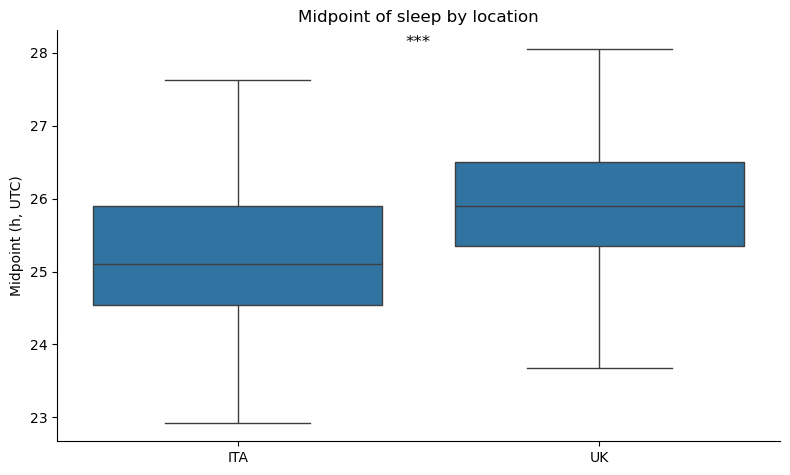

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='location', y='midpoint_h_UTC', data=df_workdays)
plt.title('Midpoint of sleep by location')
plt.suptitle('')  
plt.xlabel('')
plt.ylabel('Midpoint (h, UTC)')

plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

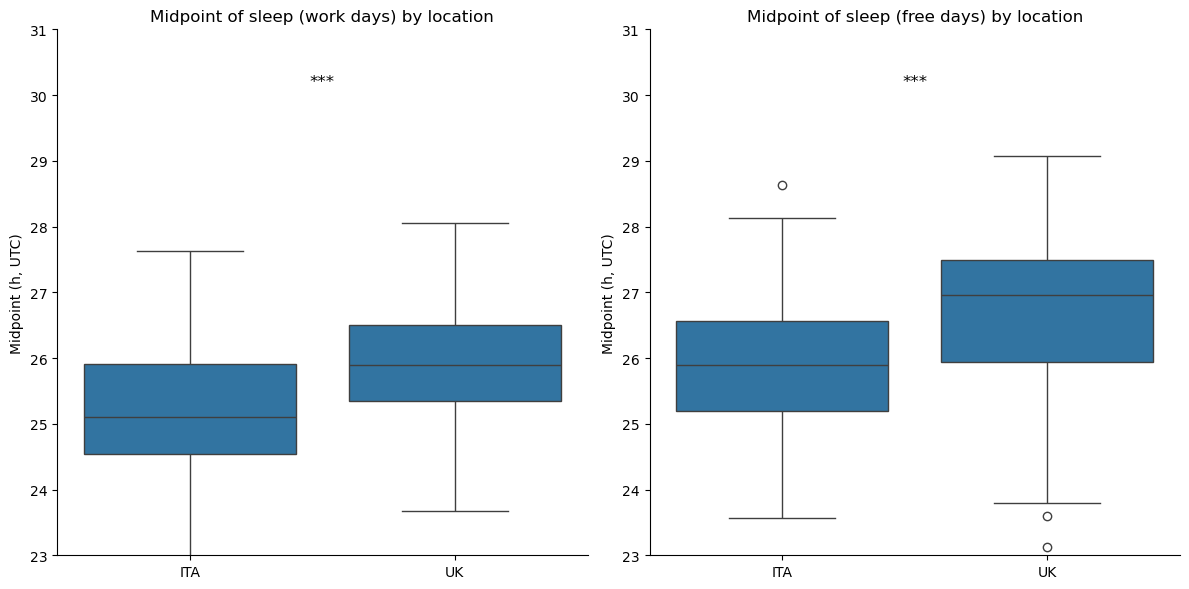

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x='location', y='midpoint_h_UTC', data=df_workdays, ax=ax[0])
ax[0].set_title('Midpoint of sleep (work days) by location')
ax[0].set_ylabel('Midpoint (h, UTC)')
ax[0].set_xlabel('')
ax[0].yaxis.set_major_locator(MultipleLocator(1))
ax[0].set_ylim(23, 31)
#add a significance line of ** for the p-value < 0.01
if ttest_midpoint_workdays_loc.pvalue < 0.001:
    ax[0].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) 

sns.boxplot(x='location', y='midpoint_h_UTC', data=df_freedays, ax=ax[1])
ax[1].set_title('Midpoint of sleep (free days) by location')
ax[1].set_ylabel('Midpoint (h, UTC)')
ax[1].set_xlabel('')
ax[1].yaxis.set_major_locator(MultipleLocator(1))
ax[1].set_ylim(ax[0].get_ylim())

#add a significance line of  for the p-value < 0.05
if ttest_midpoint_freedays_loc.pvalue < 0.001:
    ax[1].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) 
    
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.tight_layout()
plt.show()

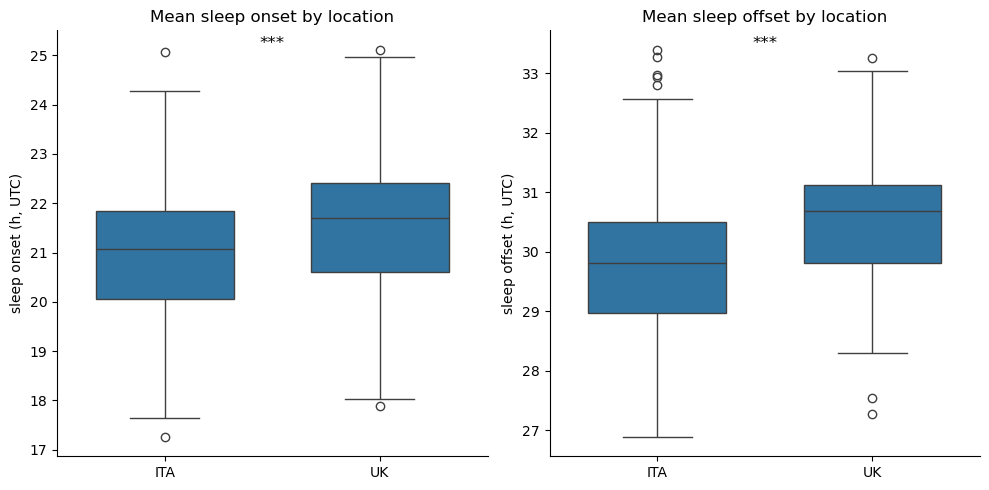

In [49]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='sleep_start_decimal_UTC', data=df, gap=0.2)
plt.title('Mean sleep onset by location')
plt.xlabel('')
plt.ylabel('sleep onset (h, UTC)')
#add a significance line to the subplot
if utest_start_loc.pvalue < 0.001:
    plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(x='location', y='sleep_end_decimal_UTC', data=df, gap=0.2)
plt.title('Mean sleep offset by location')
plt.xlabel('')
plt.ylabel('sleep offset (h, UTC)')
#add a significance line 
if utest_end_loc.pvalue < 0.001:
    plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

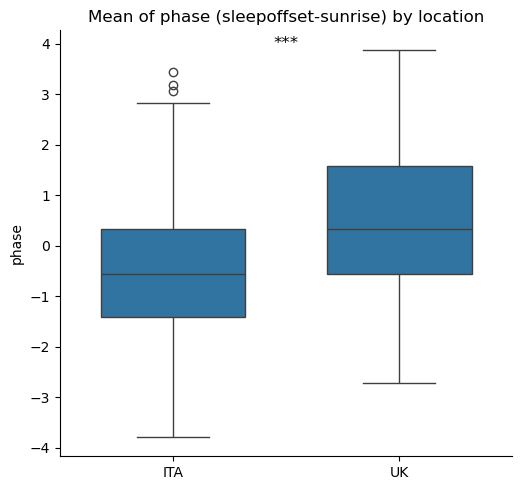

In [50]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='phase', data=df, gap=0.2)
plt.title('Mean of phase (sleepoffset-sunrise) by location')
plt.xlabel('')
plt.ylabel('phase')
#add a significance line to the subplot
if utest_phase_loc.pvalue < 0.001:
    plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

_Weekly Jetlag_

In [51]:
jetlag_clean = weekly_means_jetlag_UTC['jet lag_UTC'].dropna()

In [52]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_clean)

In [53]:
print('Shapiro test result for jet lag:')
print(shapiro_test_jetlag)

Shapiro test result for jet lag:
ShapiroResult(statistic=0.9658908356235015, pvalue=0.015610375282271051)


In [54]:
# test the difference in jet lag between the two locations
utest_jetlag = stats.mannwhitneyu(weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'ITA']['jet lag_UTC'].dropna(), weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'UK']['jet lag_UTC'].dropna())

In [55]:
print('U test result for jet lag by location:')
print(utest_jetlag)

U test result for jet lag by location:
MannwhitneyuResult(statistic=1049.5, pvalue=0.9750606867138256)


_Season and sleep-wake pattern_

In [56]:
# remove NaN values from the columns and create a new dataframe
df1 = df.dropna(subset=['sleep_duration_UTC']) 
df1 = df.dropna(subset=['phase'])

In [57]:
ols_midpoint_season = ols('midpoint_h_UTC ~ C(season)', data=df1).fit() # generate and fit the regression model
anova_midpoint_result_season = sm.stats.anova_lm(ols_midpoint_season, typ=3) # fit the ANOVA model and get the results

In [58]:
print('ANOVA Result:')
print(anova_midpoint_result_season)

ANOVA Result:
                  sum_sq     df              F        PR(>F)
Intercept  102371.567512    1.0  100113.864660  0.000000e+00
C(season)     105.640046    3.0      34.436753  1.919444e-20
Residual      574.673859  562.0            NaN           NaN


In [59]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season1 = pairwise_tukeyhsd(df1['midpoint_h_UTC'], df1['season'])
print(tukey_results_season1)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.0253  0.997 -0.2949 0.3455  False
Autumn Summer  -0.2435 0.1953 -0.5597 0.0728  False
Autumn Winter   0.8439    0.0   0.558 1.1299   True
Spring Summer  -0.2687 0.1789 -0.6102 0.0727  False
Spring Winter   0.8186    0.0   0.505 1.1323   True
Summer Winter   1.0874    0.0  0.7778  1.397   True
---------------------------------------------------


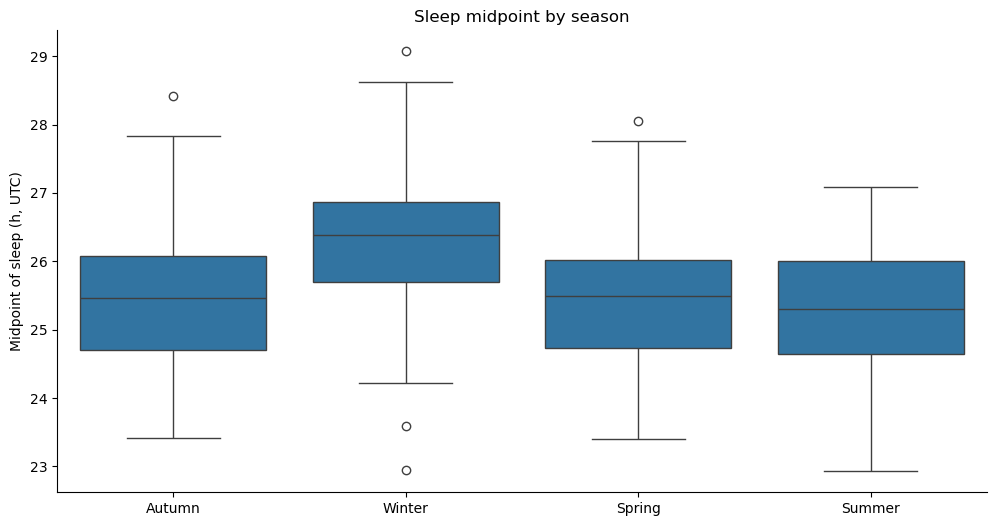

In [60]:
# sleep midpoint by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midpoint_h_UTC', data=df1)
plt.title('Sleep midpoint by season')
#plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of sleep (h, UTC)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') 
plt.gca().spines['left'].set_color('black')
plt.show()

In [61]:
# Kruskal-Wallis test 
kw_sleep_duration_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_duration_UTC'], df[df['season'] == 'Spring']['sleep_duration_UTC'], df[df['season'] == 'Summer']['sleep_duration_UTC'], df[df['season'] == 'Autumn']['sleep_duration_UTC'])
kw_phase_season = stats.kruskal(df[df['season'] == 'Winter']['phase'], df[df['season'] == 'Spring']['phase'], df[df['season'] == 'Summer']['phase'], df[df['season'] == 'Autumn']['phase'])
kw_start_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_start_decimal_UTC'], df[df['season'] == 'Spring']['sleep_start_decimal_UTC'], df[df['season'] == 'Summer']['sleep_start_decimal_UTC'], df[df['season'] == 'Autumn']['sleep_start_decimal_UTC'])
kw_end_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_end_decimal_UTC'], df[df['season'] == 'Spring']['sleep_end_decimal_UTC'], df[df['season'] == 'Summer']['sleep_end_decimal_UTC'], df[df['season'] == 'Autumn']['sleep_end_decimal_UTC'])

In [62]:
print('Results for Kruskal-Wallis test for the sleep duration by season')
print(kw_sleep_duration_season)
print('Results for Kruskal-Wallis test for the phase by season')
print(kw_phase_season)
print('Results for Kruskal-Wallis test for the sleep onset by season')
print(kw_start_season)
print('Results for Kruskal-Wallis test for the sleep offset by season')
print(kw_end_season)

Results for Kruskal-Wallis test for the sleep duration by season
KruskalResult(statistic=1.5978437208009528, pvalue=0.6598788403583598)
Results for Kruskal-Wallis test for the phase by season
KruskalResult(statistic=205.67649777702235, pvalue=2.5034834728697753e-44)
Results for Kruskal-Wallis test for the sleep onset by season
KruskalResult(statistic=53.86323177380167, pvalue=1.2000065049226613e-11)
Results for Kruskal-Wallis test for the sleep offset by season
KruskalResult(statistic=88.20097144611152, pvalue=5.332390398690246e-19)


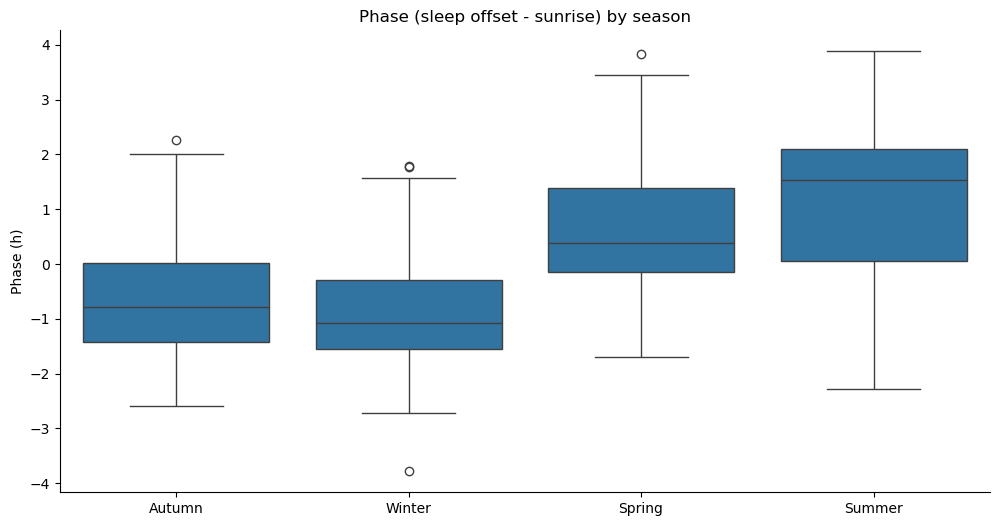

In [63]:
# phase (sleep offset - sunrise) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='phase', data=df)
plt.title('Phase (sleep offset - sunrise) by season')
plt.suptitle('')  # adding space after the title
plt.ylabel('Phase (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

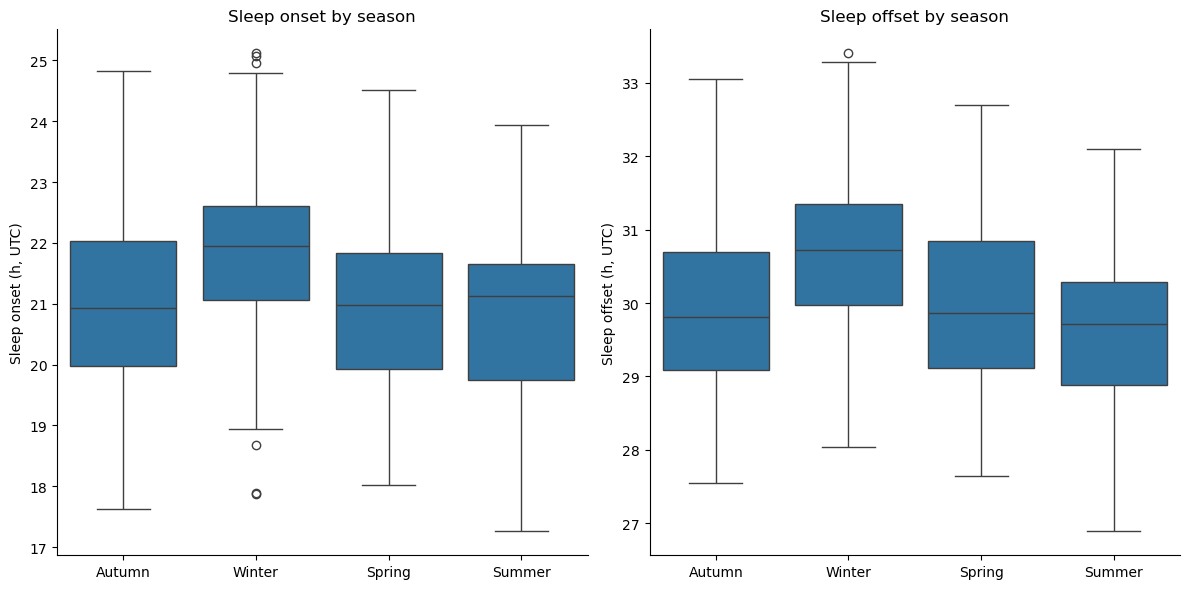

In [64]:
# sleep-wake pattern by season
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='season', y='sleep_start_decimal_UTC', data=df)
plt.title('Sleep onset by season')
plt.ylabel('Sleep onset (h, UTC)')
plt.xlabel('')

plt.subplot(1, 2, 2)
sns.boxplot(x='season', y='sleep_end_decimal_UTC', data=df)
plt.title('Sleep offset by season')
plt.ylabel('Sleep offset (h, UTC)')
plt.xlabel('')

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

_DST and sleep-wake pattern_

In [65]:
df = df.rename(columns={'DST(0=ST)': 'DST_0'})

In [66]:
df2 = df.dropna(subset=['sleep_duration_UTC'])
df2 = df.dropna(subset=['phase'])

In [67]:
ttest_sleep_midpoint_dst = stats.ttest_ind(df2[df2['DST_0'] == 0]['midpoint_h_UTC'], df2[df2['DST_0'] == 1]['midpoint_h_UTC'])

In [68]:
print('T test result for the sleep midpoint by DST:')
print(ttest_sleep_midpoint_dst)

T test result for the sleep midpoint by DST:
TtestResult(statistic=12.127071907036333, pvalue=3.072883514461234e-30, df=564.0)


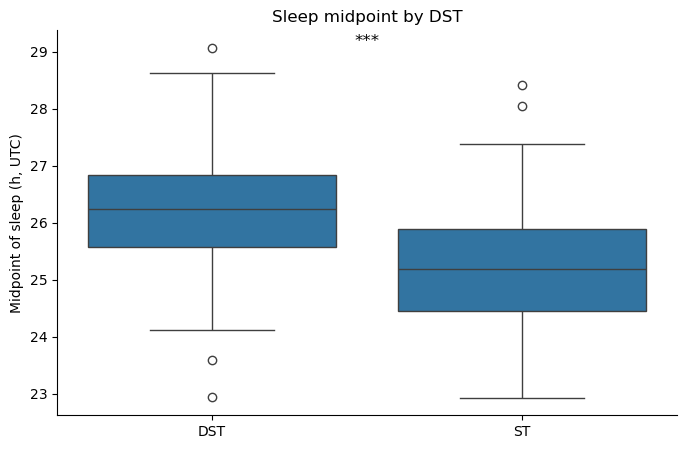

In [69]:
# Sleep midpoint by dst
plt.figure(figsize=(8, 5))
sns.boxplot(x='DST_0', y='midpoint_h_UTC', data=df2)
plt.title('Sleep midpoint by DST')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of sleep (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [70]:
# Mann Whitney U test 
utest_sleep_duration_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['sleep_duration_UTC'], df2[df2['DST_0'] == 1]['sleep_duration_UTC'])
utest_phase_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['phase'], df2[df2['DST_0'] == 1]['phase'])
utest_start_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['sleep_start_decimal_UTC'], df2[df2['DST_0'] == 1]['sleep_start_decimal_UTC'])
utest_end_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['sleep_end_decimal_UTC'], df2[df2['DST_0'] == 1]['sleep_end_decimal_UTC'])

In [71]:
print('Results for Mann-Whitney U test for the sleep duration by dst')
print(utest_sleep_duration_dst)
print('Results for Mann-Whitney U test for the phase by dst')
print(utest_phase_dst)
print('Results for Mann-Whitney U test for the sleep onset by dst')
print(utest_start_dst)
print('Results for Mann-Whitney U test for the sleep offset by dst')
print(utest_end_dst)

Results for Mann-Whitney U test for the sleep duration by dst
MannwhitneyuResult(statistic=41376.5, pvalue=0.47021257694661267)
Results for Mann-Whitney U test for the phase by dst
MannwhitneyuResult(statistic=20608.5, pvalue=2.2141842948728922e-23)
Results for Mann-Whitney U test for the sleep onset by dst
MannwhitneyuResult(statistic=55781.5, pvalue=4.15816290978017e-16)
Results for Mann-Whitney U test for the sleep offset by dst
MannwhitneyuResult(statistic=62558.5, pvalue=3.2286855812609277e-31)


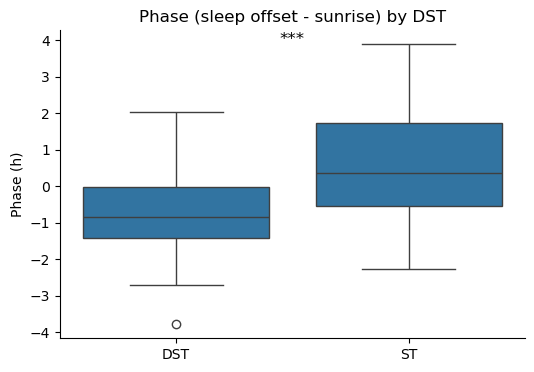

In [72]:
# Sleep Phase by dst
plt.figure(figsize=(6, 4))
sns.boxplot(x='DST_0', y='phase', data=df2)
plt.title('Phase (sleep offset - sunrise) by DST')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (h)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
sns.despine()
plt.grid(False)
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

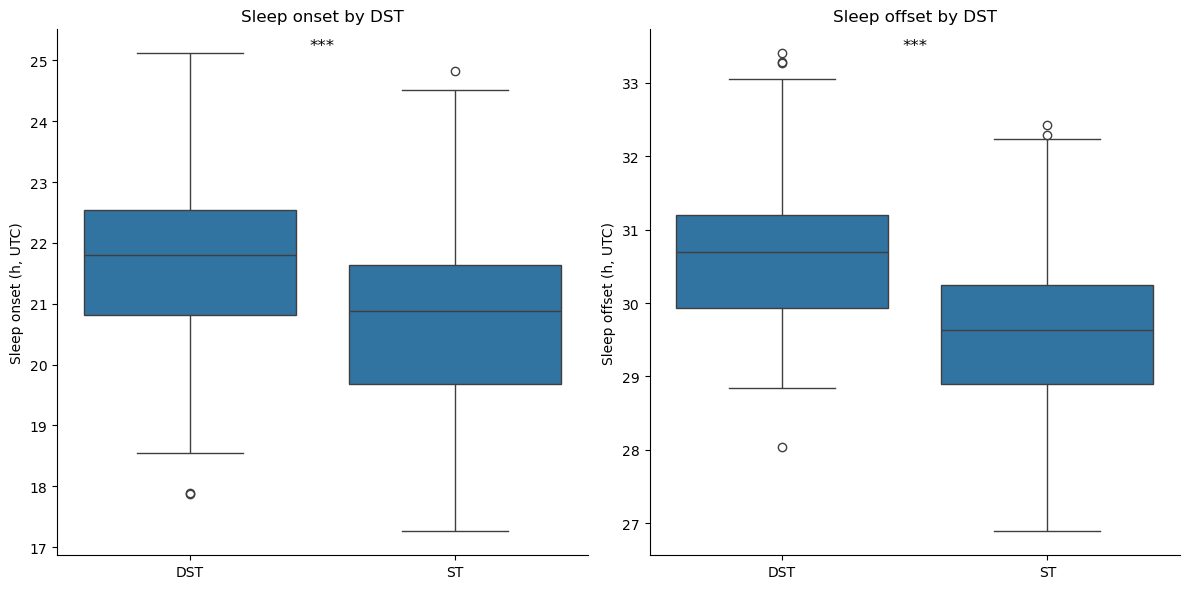

In [73]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='DST_0', y='sleep_start_decimal_UTC', data=df2)
plt.title('Sleep onset by DST')
plt.ylabel('Sleep onset (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(x='DST_0', y='sleep_end_decimal_UTC', data=df2)
plt.title('Sleep offset by DST')
plt.ylabel('Sleep offset (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

_Photoperiod and sleep-wake pattern_

In [74]:
correlation_test1 = stats.pearsonr(df['midpoint_h_UTC'], df['photoperiod'])
correlation_test2 = stats.pearsonr(df_workdays['midpoint_h_UTC'], df_workdays['photoperiod'])
correlation_test3 = stats.pearsonr(df_freedays['midpoint_h_UTC'], df_freedays['photoperiod'])
correlation_test4 = stats.spearmanr(df['sleep_duration_UTC'], df['photoperiod'])
correlation_test5 = stats.spearmanr(df['sleep_end_decimal_UTC'], df['photoperiod'])

In [75]:
# Extract the coefficients and p-values from the correlation test results
pearson_coeff = [correlation_test1.statistic, correlation_test2.statistic, correlation_test3.statistic, correlation_test4.statistic, correlation_test5.correlation]
p_values = [correlation_test1.pvalue, correlation_test2.pvalue, correlation_test3.pvalue, correlation_test4.pvalue, correlation_test5.pvalue]

# Create a DataFrame with the results
correlation_results = pd.DataFrame({
    'Variables': ['midpoint UTC vs photoperiod', 'midpoint (work) UTC vs photoperiod', 'midpoint (free) UTC vs photoperiod', 'sleep duration UTC vs photoperiod', 'sleep offset UTC vs photoperiod'],
    'Coefficient': pearson_coeff,
    'P-value': p_values
})

correlation_results

,Variables,Coefficient,P-value
0,midpoint UTC vs photoperiod,-0.368148,1.313417e-19
1,midpoint (work) UTC vs photoperiod,-0.381068,1.389815e-15
2,midpoint (free) UTC vs photoperiod,-0.390352,4.326967e-07
3,sleep duration UTC vs photoperiod,-0.016755,6.908110e-01
4,sleep offset UTC vs photoperiod,-0.390613,4.510522e-22


_Weekly IV, IS and RA_

In [76]:
# Load the datasets
weekly_values = pd.read_csv(fpath + '\\weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag_UTC

In [77]:
# Split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [78]:
# Convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [79]:
# Merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

In [80]:
merged_data.head()

,week_of_year,Date_Range,IS,IV,RA,Start_Date,End_Date,free days,work days,jet lag_UTC,location
0,41,2022-10-12 to 2022-10-18,0.593843,0.089441,0.945319,2022-10-12,2022-10-18,24.491667,25.608333,-1.116667,ITA
1,41,2022-10-12 to 2022-10-18,0.593843,0.089441,0.945319,2022-10-12,2022-10-18,25.279167,25.637500,-0.358333,UK
2,42,2022-10-19 to 2022-10-25,0.592888,0.086393,0.934961,2022-10-19,2022-10-25,24.385417,25.045000,-0.659583,UK
3,43,2022-10-26 to 2022-11-01,0.615197,0.086685,0.958284,2022-10-26,2022-11-01,25.570833,26.237500,-0.666667,ITA
4,43,2022-10-26 to 2022-11-01,0.615197,0.086685,0.958284,2022-10-26,2022-11-01,23.129167,25.030208,-1.901042,UK


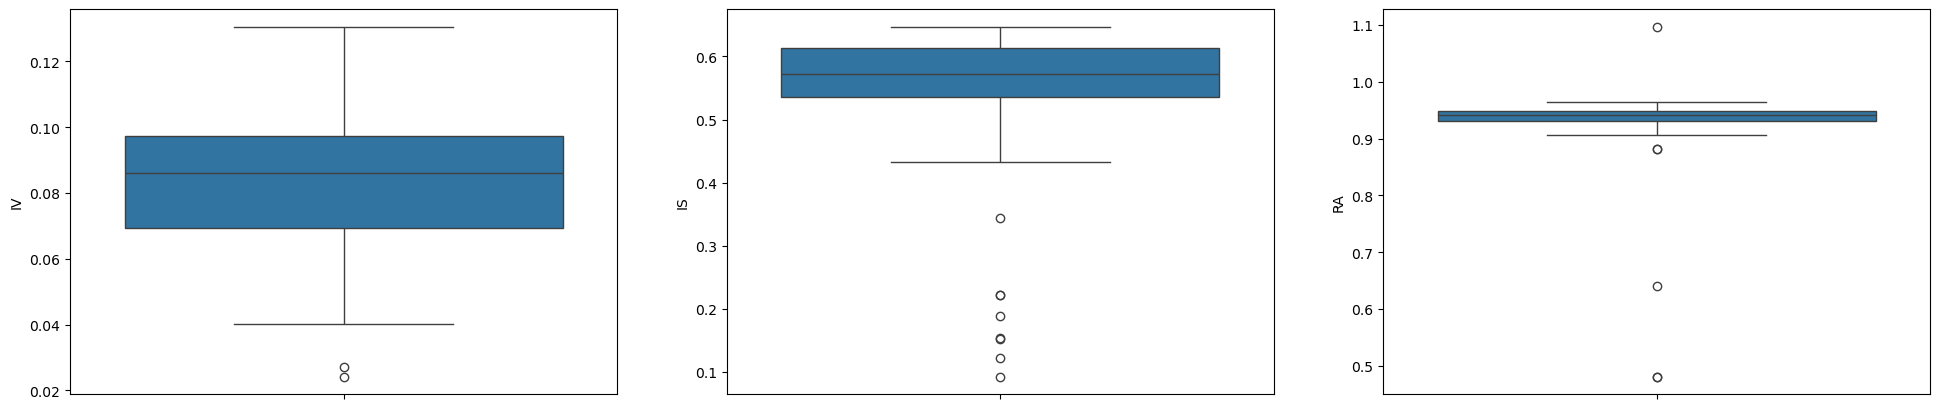

In [81]:
# box plot to verify the outliers in IV, IS, and RA
fig, ax = plt.subplots(1, 3, figsize=(24, 5))
sns.boxplot(data=merged_data['IV'], ax=ax[0])
sns.boxplot(data=merged_data['IS'], ax=ax[1])
sns.boxplot(data=merged_data['RA'], ax=ax[2])
plt.show()

In [82]:
# summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()
summary_stats

IV                                                              \
         count      mean       std       min       25%       50%       75%   
location                                                                     
ITA       53.0  0.080466  0.022129  0.024172  0.067942  0.082638  0.093785   
UK        36.0  0.088307  0.017596  0.053677  0.075609  0.087177  0.098561   

                      IS            ...                        RA            \
               max count      mean  ...       75%       max count      mean   
location                            ...                                       
ITA       0.130562  53.0  0.534746  ...  0.614026  0.647358  52.0  0.934354   
UK        0.130562  36.0  0.546748  ...  0.612065  0.645810  36.0  0.916700   

                                                                      
               std       min       25%       50%       75%       max  
location                                                              
ITA       0.069393  0.480668  0.931915  0.942574  0.951111  1.097278  
UK        0.091243  0.480668  0.922486  0.941753  0.946843  0.962952  

[2 rows x 24 columns]

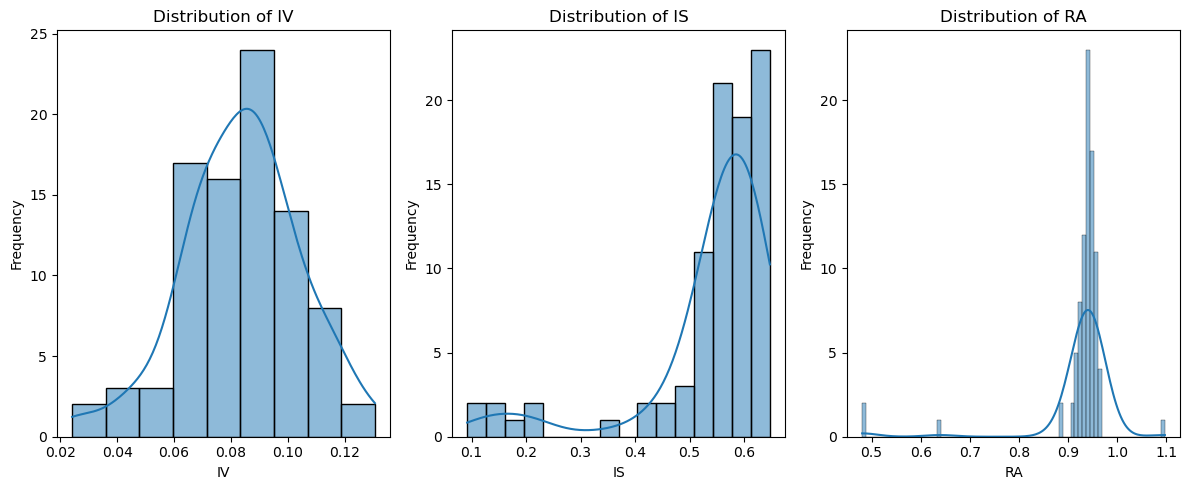

In [83]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title('Distribution of IV')
plt.xlabel('IV')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')
 
plt.subplot(1, 3, 3)
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title('Distribution of RA')
plt.xlabel('RA')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [84]:
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_ttest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [85]:
print('Test results for IV by location:', iv_ttest)
print('Test results for IS by location:', is_ttest)
print('Test results for RA by location:', ra_ttest)

Test results for IV by location: TtestResult(statistic=-1.7772445658632356, pvalue=0.07902284498496112, df=87.0)
Test results for IS by location: MannwhitneyuResult(statistic=968.0, pvalue=0.9101377845316613)
Test results for RA by location: TtestResult(statistic=1.0304626188970347, pvalue=0.30568225459077514, df=86.0)


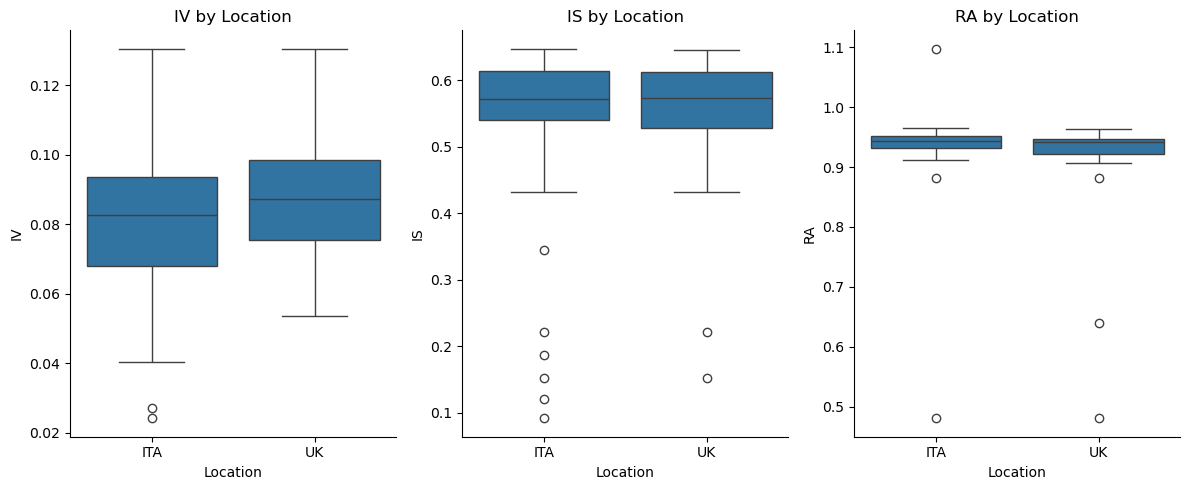

In [86]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='location', y='IV', data=merged_data)
plt.title('IV by Location')
plt.xlabel('Location')
plt.ylabel('IV')
 
plt.subplot(1, 3, 2)
sns.boxplot(x='location', y='IS', data=merged_data)
plt.title('IS by Location')
plt.xlabel('Location')
plt.ylabel('IS')

plt.subplot(1, 3, 3)
sns.boxplot(x='location', y='RA', data=merged_data)
plt.title('RA by Location')
plt.xlabel('Location')
plt.ylabel('RA')

sns.despine()
plt.tight_layout()
plt.show()

_Midsleep vs days after flight_

In [87]:
df.to_csv(fpath + '\\6.2_database_variables_cleaned.csv')

In [88]:
midsleep_bydays_after_flight = df[df['day_after_flight'] <= 7]

In [89]:
midsleep_bydays_after_flight_uk = midsleep_bydays_after_flight[midsleep_bydays_after_flight['location'] == 'UK']
midsleep_bydays_after_flight_ita = midsleep_bydays_after_flight[midsleep_bydays_after_flight['location'] == 'ITA']

In [90]:
#midsleep_bydays_after_flight['ID'] = midsleep_bydays_after_flight.index

In [91]:
# Simple linear regression analysis
model = ols('midpoint_h_UTC ~ day_after_flight', data=midsleep_bydays_after_flight_uk).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         midpoint_h_UTC   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.5482
Date:                Tue, 19 Nov 2024   Prob (F-statistic):              0.460
Time:                        17:28:32   Log-Likelihood:                -185.20
No. Observations:                 128   AIC:                             374.4
Df Residuals:                     126   BIC:                             380.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           26.1860      0.205  

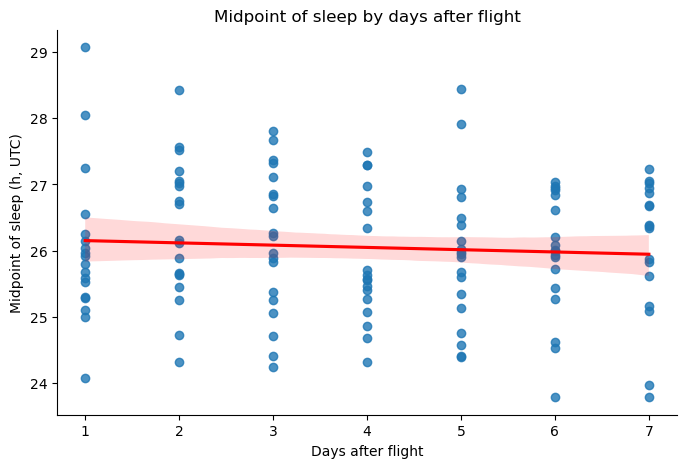

In [92]:
# Plot the regression line
plt.figure(figsize=(8, 5))
sns.regplot(x='day_after_flight', y='midpoint_h_UTC', data=midsleep_bydays_after_flight_uk, line_kws={'color': 'red'})
plt.title('Midpoint of sleep by days after flight')
plt.xlabel('Days after flight')
plt.ylabel('Midpoint of sleep (h, UTC)')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [93]:
# Simple linear regression analysis
model = ols('midpoint_h_UTC ~ day_after_flight', data=midsleep_bydays_after_flight_ita).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         midpoint_h_UTC   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     6.761
Date:                Tue, 19 Nov 2024   Prob (F-statistic):             0.0103
Time:                        17:28:32   Log-Likelihood:                -213.85
No. Observations:                 144   AIC:                             431.7
Df Residuals:                     142   BIC:                             437.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           25.8285      0.199  

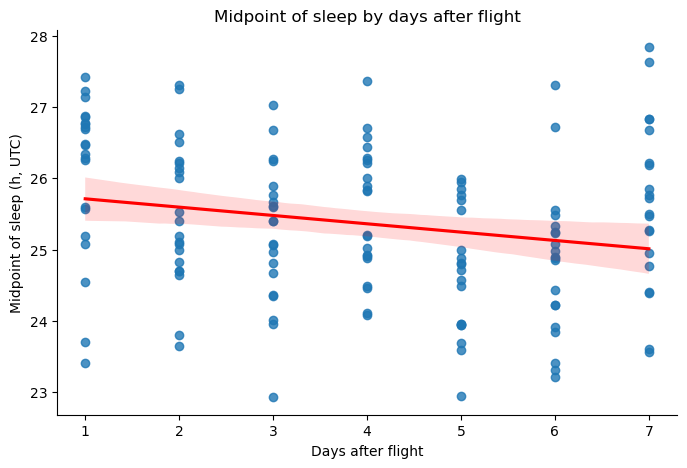

In [94]:
# Plot the regression line
plt.figure(figsize=(8, 5))
sns.regplot(x='day_after_flight', y='midpoint_h_UTC', data=midsleep_bydays_after_flight_ita, line_kws={'color': 'red'})
plt.title('Midpoint of sleep by days after flight')
plt.xlabel('Days after flight')
plt.ylabel('Midpoint of sleep (h, UTC)')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [96]:
# An AnovaRM in Python could be performed only if fully balanced (i.e., only fully within-subject designs are supported). 
# One general limitation for the Python implementations is that crossed random-effects are not supported, so only one factor can be specified to model the random effects
# my_model_fit = AnovaRM(midsleep_bydays_after_flight_clean, 'midpoint_h_UTC', 'ID', within=['day_after_flight', 'location']).fit()
# print(my_model_fit.anova_table)

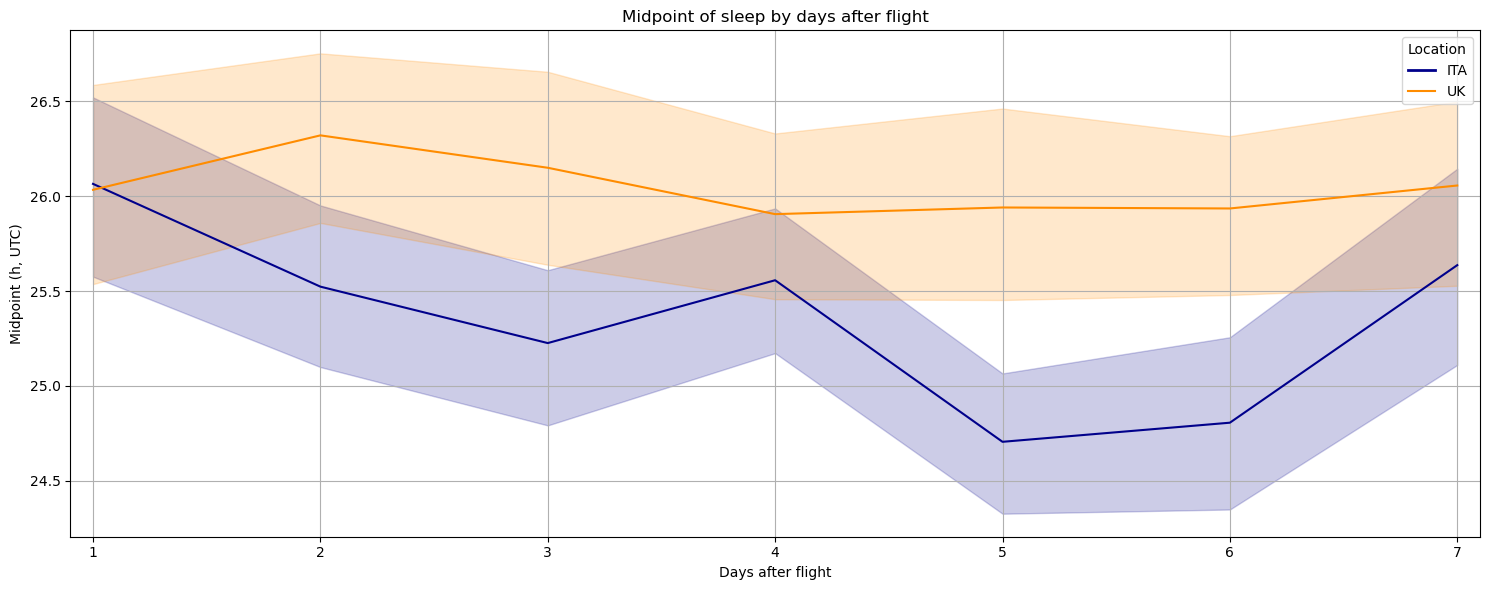

In [97]:
plt.figure(figsize=(15, 6))
sns.lineplot(x='day_after_flight', y='midpoint_h_UTC', hue='location', data=midsleep_bydays_after_flight, palette=['darkblue', 'darkorange'])
plt.title('Midpoint of sleep by days after flight')
plt.xlabel('Days after flight')
plt.ylabel('Midpoint (h, UTC)')
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange')])
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.xlim(0.9, 7.1)

plt.gca().xaxis.set_major_locator(MultipleLocator(1)) 

plt.show()

_Midpoint by location, days of the week and photoperiod_

# ONGOING: test the effect of season, DST and location on midsleep by days after flight

In [98]:
model_1 = ols('midpoint_h_UTC ~ C(location) * C(weekday_type)', data=df).fit() # C() is used to indicate categorical variables

In [99]:
anova_results = sm.stats.anova_lm(model_1, typ=3)

In [100]:
print(model_1.summary())
print("")
print("ANOVA Results:")
print(anova_results)

                            OLS Regression Results                            
Dep. Variable:         midpoint_h_UTC   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     39.86
Date:                Tue, 19 Nov 2024   Prob (F-statistic):           2.29e-23
Time:                        17:28:33   Log-Likelihood:                -800.58
No. Observations:                 566   AIC:                             1609.
Df Residuals:                     562   BIC:                             1627.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

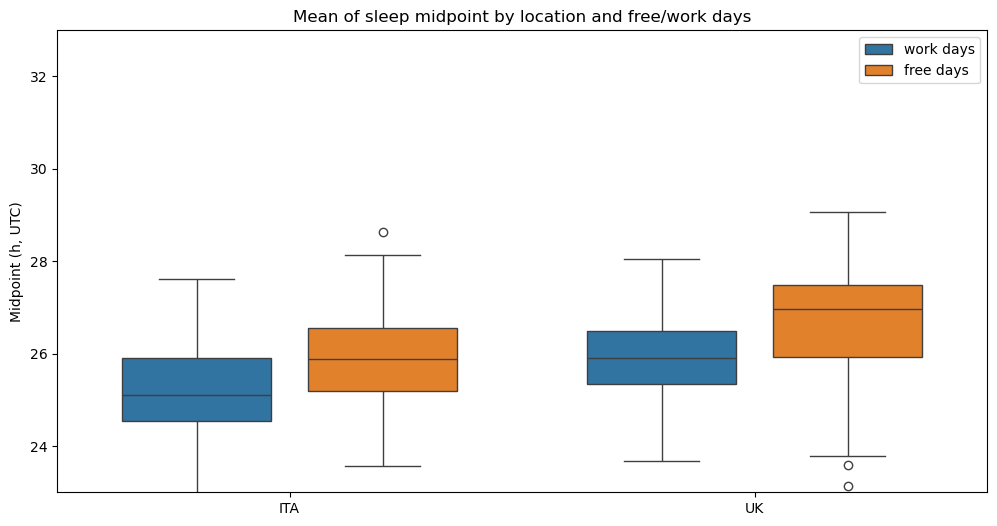

In [101]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='midpoint_h_UTC', hue='weekday_type', data=df, gap=0.2)
plt.title('Mean of sleep midpoint by location and free/work days')
plt.xlabel('')
plt.ylim(23, 33)
plt.ylabel('Midpoint (h, UTC)')
plt.legend()
plt.show()

In [102]:
model_Y = smf.ols('midpoint_h_UTC ~ C(location) * C(weekday_type) * photoperiod', data=df).fit()

In [103]:
anova_results_x = sm.stats.anova_lm(model_Y, typ=3)

In [104]:
print(model_Y.summary())
print("ANOVA Results:")
print(anova_results_x)

                            OLS Regression Results                            
Dep. Variable:         midpoint_h_UTC   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     36.29
Date:                Tue, 19 Nov 2024   Prob (F-statistic):           7.64e-42
Time:                        17:28:33   Log-Likelihood:                -749.00
No. Observations:                 566   AIC:                             1514.
Df Residuals:                     558   BIC:                             1549.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

_Phase by location, time_

In [105]:
data_phase = df.dropna(subset=['phase', 'location', 'date', 'photoperiod'])

In [106]:
data_phase['location'] = data_phase['location'].map({'ITA': 0, 'UK': 1}) # convert the location to numerical values

In [107]:
# Converting date to numerical values (days since the start of the observation period)
data_phase['date_numeric'] = (pd.to_datetime(data_phase['date']) - pd.to_datetime(data_phase['date']).min()).dt.days

In [108]:
glm_model_phase_numeric1 = smf.glm(
    formula="phase ~ location + photoperiod ",
    data=data_phase,
    family=sm.families.Gaussian()
)

In [109]:
# Fit of the model
glm_results_phase_numeric1 = glm_model_phase_numeric1.fit()

In [110]:
# Output the summary of the model
glm_results_phase_numeric_summary1 = glm_results_phase_numeric1.summary()
glm_results_phase_numeric_summary1

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  phase   No. Observations:                  566
Model:                            GLM   Df Residuals:                      563
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                         0.88599
Method:                          IRLS   Log-Likelihood:                -767.36
Date:                Tue, 19 Nov 2024   Deviance:                       498.81
Time:                        17:28:33   Pearson chi2:                     499.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.6770
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -4.3743      0.182    -24.070      0.000      -4.730      -4.018
location        0.9110      0.081     11.301      0.000       0.753       1.069
photoperiod     0.3353      0.015     22.634      0.000       0.306       0.364
===============================================================================
"""

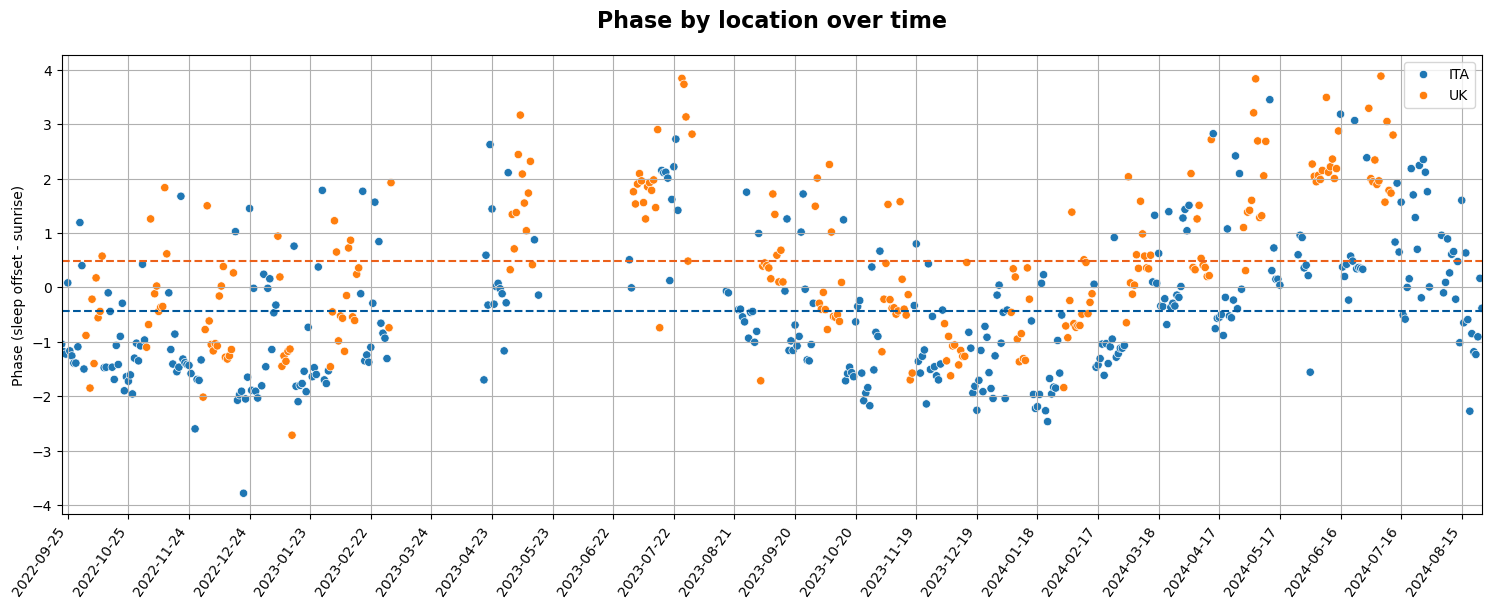

In [111]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase', hue='location', data=df)
plt.title('Phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())

# get the current axes then set the x-axis major locator
# plot.gca()=ax if set ax = plt.gca()
plt.gca().xaxis.set_major_locator(MultipleLocator(30)) 

#add the mean of the phase for the two locations
plt.axhline(df[df['location'] == 'ITA']['phase'].mean(), color='#00589c', linestyle='--', label='ITA mean')
plt.axhline(df[df['location'] == 'UK']['phase'].mean(), color='#ec611a', linestyle='--', label='UK mean')

plt.show()

_Phase by location and week day_

In [112]:
data_phase2 = df.dropna(subset=['phase', 'location', 'weekday_type'])

In [113]:
glm_model_phase2 = smf.glm(
    formula="phase ~ location + weekday_type",
    data=data_phase2,
    family=sm.families.Gaussian()
)

In [114]:
# Fit of the model
glm_results_phase2 = glm_model_phase2.fit()

In [115]:
# Output the summary of the model (ita and free days as baseline)
glm_results_phase2_summary = glm_results_phase2.summary()
glm_results_phase2_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  phase   No. Observations:                  566
Model:                            GLM   Df Residuals:                      563
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          1.5307
Method:                          IRLS   Log-Likelihood:                -922.10
Date:                Tue, 19 Nov 2024   Deviance:                       861.81
Time:                        17:28:34   Pearson chi2:                     862.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2096
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.2096      0.107      1.963      0.050       0.000       0.419
location[T.UK]                0.9331      0.106      8.803      0.000       0.725       1.141
weekday_type[T.work days]    -0.8954      0.116     -7.705      0.000      -1.123      -0.668
=============================================================================================
"""

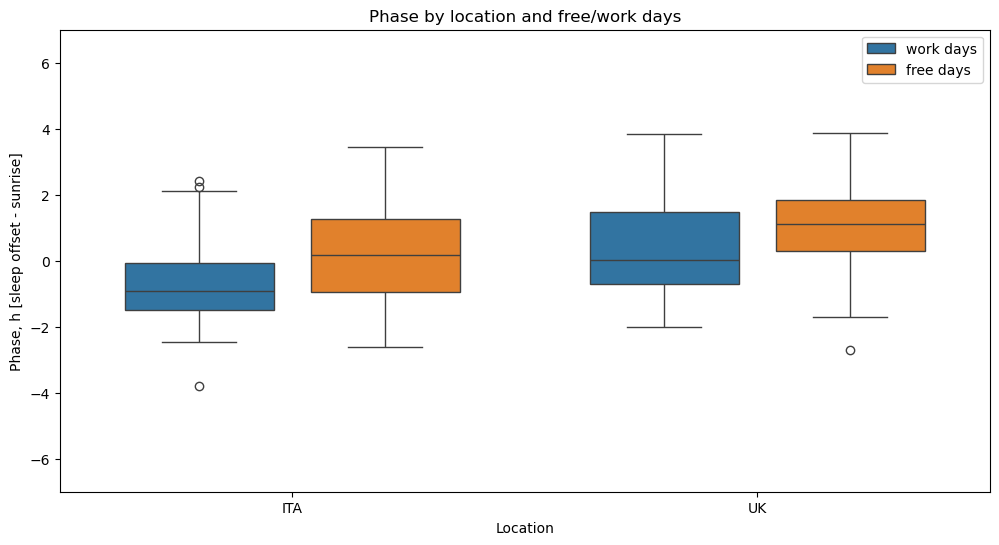

In [116]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='phase', hue='weekday_type', data=data_phase2, gap=0.2)
plt.title('Phase by location and free/work days')
plt.xlabel('Location')
plt.ylim(-7,7)
plt.ylabel('Phase, h [sleep offset - sunrise]')
plt.legend()

plt.show()